In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier


In [10]:
titanic=sns.load_dataset("titanic")
features=["age", "embarked", "pclass", "sex", "fare"]
target=["survived"]

#handle missing values
imp_mean=SimpleImputer(strategy="median")
titanic[["age"]]=imp_mean.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

#encoding
le=LabelEncoder()

titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])


X=titanic[features]
y=titanic["survived"]

#train test split

X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
#decision tree

model=DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred_test=model.predict(X_test)
y_pred_train=model.predict(X_train)

print("training accuracy_score:", accuracy_score(y_train, y_pred_train))
print("testing accuracy_score:", accuracy_score(y_test, y_pred_test))
# classic case of overfitting

training accuracy_score: 0.9775280898876404
testing accuracy_score: 0.7653631284916201


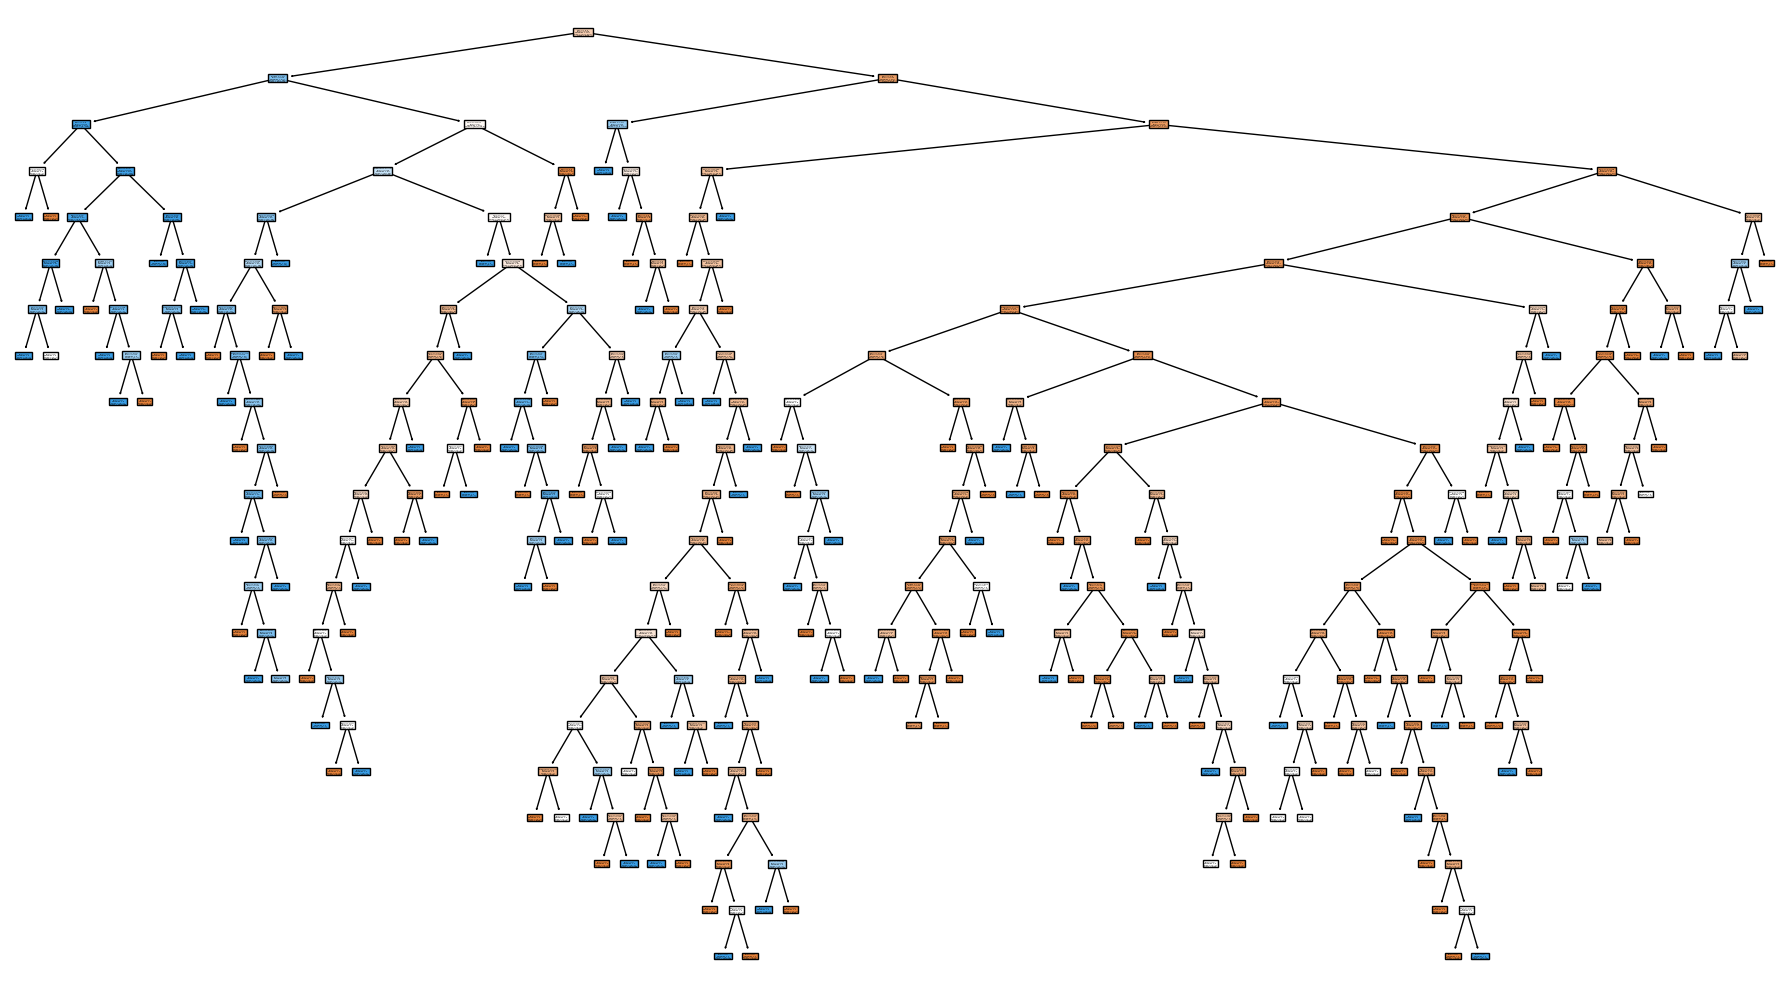

In [12]:
#plot tree
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
)

plt.tight_layout()
plt.show()

In [14]:
#random forest classifier to fix overfitting
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=201,
    oob_score=True
)

rf.fit(X_train, y_train)

y_pred=rf.predict(X_test)

print("OOB score:", rf.oob_score_*100, "%")
print("testing accuracy:", accuracy_score(y_test, y_pred)*100, "%")


OOB score: 80.47752808988764 %
testing accuracy: 79.3296089385475 %


In [15]:
# bagging using Decision Tree classifier

base_model=DecisionTreeClassifier()

from sklearn.ensemble import BaggingClassifier

bagging=BaggingClassifier(
    base_model,
    n_estimators=201
)


bagging.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=201)

In [17]:
y_pred=bagging.predict(X_test)

print("accuracy_score:", accuracy_score(y_test, y_pred))

accuracy_score: 0.8044692737430168
